### 数据集

In [221]:
import numpy as np
import matplotlib.pyplot as plt

In [222]:
from sklearn.datasets import fetch_lfw_people  # 导入 LFW（Labeled Faces in the Wild）人脸数据集

In [223]:
lfw_people = fetch_lfw_people()

In [224]:
print(lfw_people.DESCR)

.. _labeled_faces_in_the_wild_dataset:

The Labeled Faces in the Wild face recognition dataset
------------------------------------------------------

This dataset is a collection of JPEG pictures of famous people collected
over the internet, and the details are available on the Kaggle website:

https://www.kaggle.com/datasets/jessicali9530/lfw-dataset

Each picture is centered on a single face. The typical task is called
Face Verification: given a pair of two pictures, a binary classifier
must predict whether the two images are from the same person.

An alternative task, Face Recognition or Face Identification is:
given the picture of the face of an unknown person, identify the name
of the person by referring to a gallery of previously seen pictures of
identified persons.

Both Face Verification and Face Recognition are tasks that are typically
performed on the output of a model trained to perform Face Detection. The
most popular model for Face Detection is called Viola-Jones and is
i

In [225]:
X = lfw_people.data
y = lfw_people.target

In [226]:
X.shape, y.shape

((13233, 2914), (13233,))

In [227]:
n_samples, h, w = lfw_people.images.shape  # images 的形状为：(样本数量, 图片高度, 图片宽度)
n_samples, h, w                            # 查看样本数、图片高度和图片宽度

(13233, 62, 47)

In [228]:
y[:10]  # 查看前 10 张图片对应的人物类别编号

array([5360, 3434, 3807,   26, 3957,  439, 2683, 3734, 5465, 3445])

In [229]:
lfw_people.target_names  # 查看所有类别编号对应的人物姓名

array(['AJ Cook', 'AJ Lamas', 'Aaron Eckhart', ..., 'Zumrati Juma',
       'Zurab Tsereteli', 'Zydrunas Ilgauskas'],
      shape=(5749,), dtype='<U35')

In [230]:
lfw_people.target_names.shape  # 查看数据集中人物类别的数量

(5749,)

In [231]:
def plot_faces(data, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.xticks(())
        plt.yticks(())
        plt.imshow(data[i].reshape((h, w)), cmap=plt.cm.gray)
    plt.show()

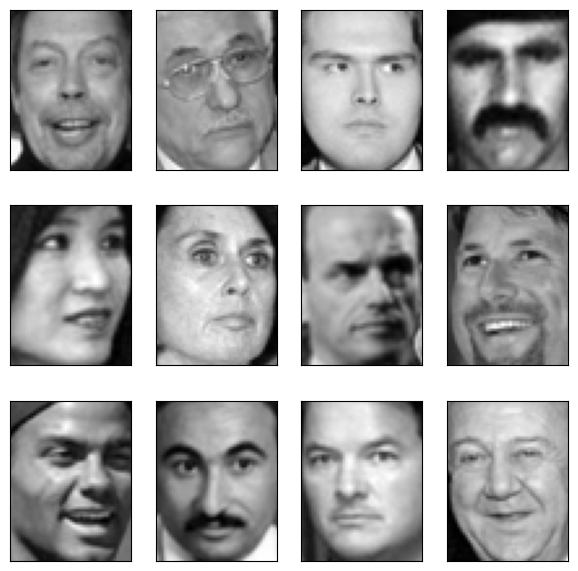

In [232]:
plot_faces(X, h, w)

### 数据处理

In [233]:
# 只保留至少拥有 70 张照片的人物，resize=0.4：将原始图片缩小到原尺寸的 40%，减少计算量
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

In [234]:
X = lfw_people.data    # 获取处理后的人脸特征矩阵
y = lfw_people.target  # 获取对应的人物类别标签

In [235]:
X.shape, y.shape

((1288, 1850), (1288,))

In [236]:
n_samples, h, w = lfw_people.images.shape  # 获取样本数、图片高度和图片宽度
n_samples, h, w                            # 查看样本数、图片高度和图片宽度

(1288, 50, 37)

In [237]:
lfw_people.target_names  # 查看筛选后保留下来的人物姓名

array(['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
       'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair'], dtype='<U17')

In [238]:
lfw_people.target_names.shape  # 查看类别数量

(7,)

In [239]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [240]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [241]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [242]:
X_train.shape, X_test.shape

((966, 1850), (322, 1850))

### PCA降维

In [243]:
from sklearn.decomposition import PCA
pca = PCA(n_components=150, random_state=42)  # 创建 PCA 模型，将原来的 1850 个特征降维到 150 个主成分
pca.fit(X_train);  # 使用训练集拟合 PCA，学习数据中主要的变化方向

In [244]:
pca.components_.shape  # 查看 PCA 主成分矩阵的形状，表示(主成分数量, 原始特征数量)

(150, 1850)

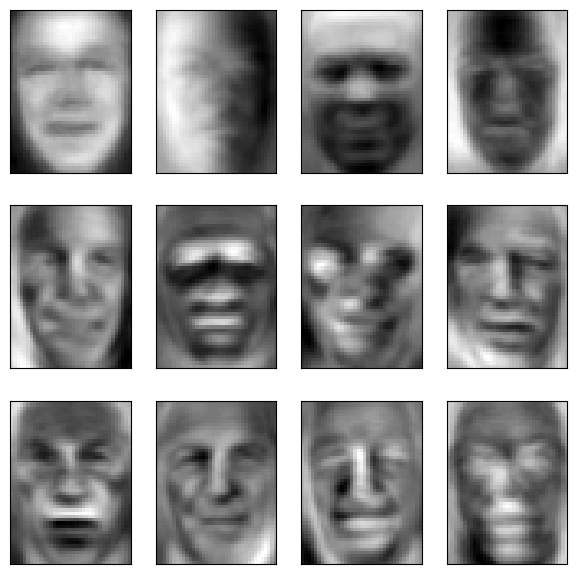

In [245]:
# 将 PCA 的主成分重新还原成人脸图片并进行可视化，每个主成分可以理解为一种典型的人脸特征模式，即“特征脸”
plot_faces(pca.components_, h, w)

In [246]:
X_train_pca = pca.transform(X_train)  # 使用训练好的 PCA 模型，将训练集从 1850 维降到 150 维
X_test_pca = pca.transform(X_test)    # 使用相同的 PCA 模型对测试集进行降维

### 人脸识别

In [247]:
from sklearn.svm import SVC  # 导入支持向量机分类器 SVC，用于进行人脸分类

In [248]:
clf = SVC(C=10)  # 创建 SVM 分类模型，C=10：控制对分类错误的惩罚程度，C 越大越倾向于减少训练误差
clf.fit(X_train_pca, y_train)  # 使用 PCA 降维后的训练数据进行模型训练
clf.score(X_test_pca, y_test)  # 在 PCA 降维后的测试集上计算分类准确率

0.8322981366459627

In [249]:
clf = SVC(C=10)
clf.fit(X_train, y_train)  # 直接使用原始的标准化人脸特征训练模型
clf.score(X_test, y_test)  # 在原始测试数据上计算分类准确率

0.8229813664596274

In [250]:
# 可以看到，这次实验中 PCA 将特征从 1850 维降到 150 维后，准确率没有下降，反而略有提高。